In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("VS Code setup complete!")
print("Python interpreter:", sys.executable)
print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)
import numpy as np
from sklearn.model_selection import train_test_split
import scipy.optimize as opt


VS Code setup complete!
Python interpreter: c:\Users\billy\Projects\project_02\.venv\Scripts\python.exe
NumPy version: 2.5.3
pandas version: 3.0.6


**Task 1**

In [2]:
#1,2
df_raw = pd.read_csv("ims_setup_project02.csv")

display(df_raw.head())
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
print("Column names:", list(df_raw.columns))
display(df_raw.describe())
print("Missing values per column:")
print(df_raw.isna().sum())

,lap,rear_wing_angle_deg,rear_ride_height_mm,sector_3_time_s,top_speed_kph
0,1,5,35,33.0949,286.761
1,2,5,35,32.9325,287.079
2,3,5,35,33.0858,287.261
3,4,5,35,33.0472,287.059
4,5,5,35,33.0534,287.463


Rows: 135, Columns: 5
Column names: ['lap', 'rear_wing_angle_deg', 'rear_ride_height_mm', 'sector_3_time_s', 'top_speed_kph']


,lap,rear_wing_angle_deg,rear_ride_height_mm,sector_3_time_s,top_speed_kph
count,135.000000,135.000000,135.000000,135.000000,135.000000
mean,3.000000,9.000000,40.000000,31.803734,284.178563
std,1.419481,2.591605,4.097688,0.542766,1.778668
min,1.000000,5.000000,35.000000,31.061300,280.887000
25%,2.000000,7.000000,35.000000,31.413650,282.690500
50%,3.000000,9.000000,40.000000,31.599500,284.373000
75%,4.000000,11.000000,45.000000,32.041350,285.638000
max,5.000000,13.000000,45.000000,33.094900,287.463000


Missing values per column:
lap                    0
rear_wing_angle_deg    0
rear_ride_height_mm    0
sector_3_time_s        0
top_speed_kph          0
dtype: int64


In [3]:
#3
df = df_raw[["lap", "rear_wing_angle_deg", "rear_ride_height_mm",
             "sector_3_time_s", "top_speed_kph"]].copy()

df["lap"] = pd.to_numeric(df["lap"], errors="coerce")
df["rear_wing_angle_deg"] = pd.to_numeric(df["rear_wing_angle_deg"], errors="coerce")
df["rear_ride_height_mm"] = pd.to_numeric(df["rear_ride_height_mm"], errors="coerce")
df["sector_3_time_s"] = pd.to_numeric(df["sector_3_time_s"], errors="coerce")
df["top_speed_kph"] = pd.to_numeric(df["top_speed_kph"], errors="coerce")

df = df.drop_duplicates()
df = df.dropna()

print("Rows after cleaning:", len(df))

Rows after cleaning: 135


In [4]:
#4 5 6
df_grouped = (
    df.groupby(["rear_wing_angle_deg", "rear_ride_height_mm"], as_index=False)
      .agg(
          mean_sector_3_time_s=("sector_3_time_s", "mean"),
          std_sector_3_time_s=("sector_3_time_s", "std"),
          mean_top_speed_kph=("top_speed_kph", "mean"),
          std_top_speed_kph=("top_speed_kph", "std"),
          valid_laps=("sector_3_time_s", "count")
      )
)

display(df_grouped)
print("Number of unique setup configurations:", len(df_grouped))
df_grouped.to_csv(f"Wfrazer_pr02_grouped.csv", index=False)

,rear_wing_angle_deg,rear_ride_height_mm,mean_sector_3_time_s,std_sector_3_time_s,mean_top_speed_kph,std_top_speed_kph,valid_laps
0,5,35,33.04276,0.064925,287.1246,0.260628,5
1,5,40,32.85104,0.104126,286.7078,0.260848,5
2,5,45,32.99286,0.022043,286.6164,0.061272,5
3,6,35,32.51308,0.053101,286.5346,0.172712,5
4,6,40,32.38096,0.050323,286.2574,0.229553,5
5,6,45,32.44690,0.077138,285.7634,0.171296,5
6,7,35,32.03248,0.035651,285.8530,0.289042,5
7,7,40,31.86244,0.059775,285.3564,0.242663,5
8,7,45,32.01484,0.053106,285.0412,0.182341,5
9,8,35,31.68490,0.054910,285.3770,0.150690,5


Number of unique setup configurations: 27


In [5]:
#8
df_train, df_test = train_test_split(
    df_grouped,
    test_size=0.25,
    random_state=42
)

#8
print("Training setups:", len(df_train))
print("Test setups:", len(df_test))

Training setups: 20
Test setups: 7


**#8 cont**
Data leakage happens when information from the test data directly or indirectly influences model training. 

The raw data had 5 laps for each of the 27 setup iterations. If you were to randomly assign via lap, some laps from a setup could end up in training and others from the same setup in testing. The model would then just be predicting another repetition of a setup it has already seen, not a genuinely new setup, and the test RMSE and $R^2$ would be unrealistically optimistic. This was discussed in Lecture 7.

Instead, df_grouped has one row per unique setup, so each setup is either entirely in training or entirely in testing. 

This gives 20 training setups and 7 test setups. The training data is used only to estimate the coefficients, and the 7 test setups are used only to check predictions, so the test metrics show predictive performance on unseen setups rather than just goodness of fit. Averaging the 5 laps first also removes lap to lap noise before fitting.

In [6]:
#9
def create_design_matrix(x1, x2):
    X = pd.DataFrame({
        "const": np.ones(len(x1)),
        "x1": x1,
        "x2": x2,
        "x1_sq": x1**2,
        "x2_sq": x2**2,
        "x1_x2": x1*x2
    })
    return X.to_numpy()

In [7]:
# Training features
x1_train = df_train["rear_wing_angle_deg"].values
x2_train = df_train["rear_ride_height_mm"].values

# Training design matrix
Xdm_train = create_design_matrix(x1_train, x2_train)

# Training responses
y_time_train = df_train["mean_sector_3_time_s"].values
y_speed_train = df_train["mean_top_speed_kph"].values

display(pd.DataFrame(Xdm_train, columns=["const", "x1", "x2", "x1_sq", "x2_sq", "x1_x2"]))
print("Design matrix shape:", Xdm_train.shape)

,const,x1,x2,x1_sq,x2_sq,x1_x2
0,1.0,10.0,45.0,100.0,2025.0,450.0
1,1.0,9.0,35.0,81.0,1225.0,315.0
2,1.0,13.0,35.0,169.0,1225.0,455.0
3,1.0,5.0,40.0,25.0,1600.0,200.0
4,1.0,6.0,40.0,36.0,1600.0,240.0
5,1.0,6.0,45.0,36.0,2025.0,270.0
6,1.0,5.0,45.0,25.0,2025.0,225.0
7,1.0,10.0,35.0,100.0,1225.0,350.0
8,1.0,12.0,40.0,144.0,1600.0,480.0
9,1.0,6.0,35.0,36.0,1225.0,210.0


Design matrix shape: (20, 6)


In [8]:
#10 11 12

b_time_train = np.linalg.pinv(Xdm_train) @ y_time_train


b_speed_train = np.linalg.pinv(Xdm_train) @ y_speed_train


np.set_printoptions(suppress=True, precision=6)
print("Coefficient order: [b0, b1, b2, b3, b4, b5] = [const, x1, x2, x1^2, x2^2, x1*x2]")
print("b_time_train: ", b_time_train)
print("b_speed_train:", b_speed_train)

Coefficient order: [b0, b1, b2, b3, b4, b5] = [const, x1, x2, x1^2, x2^2, x1*x2]
b_time_train:  [47.388688 -1.298382 -0.480678  0.054343  0.005671  0.003882]
b_speed_train: [295.038265  -0.555986  -0.202484  -0.00722    0.001703   0.000335]


In [9]:
#13 14
# Test design matrix (same function, so the same terms in the same order)
x1_test = df_test["rear_wing_angle_deg"].values
x2_test = df_test["rear_ride_height_mm"].values
Xdm_test = create_design_matrix(x1_test, x2_test)

# Observed test responses
y_time_test = df_test["mean_sector_3_time_s"].values
y_speed_test = df_test["mean_top_speed_kph"].values

# 13. Predict at the unseen setups
yhat_time_test = Xdm_test @ b_time_train
yhat_speed_test = Xdm_test @ b_speed_train

# 14. Test residuals
res_time = y_time_test - yhat_time_test
res_speed = y_speed_test - yhat_speed_test

# Root mean squared error
rmse_time = np.sqrt(np.mean(res_time**2))
rmse_speed = np.sqrt(np.mean(res_speed**2))

# Test-set R-squared
r2_time = 1 - np.sum(res_time**2) / np.sum((y_time_test - np.mean(y_time_test))**2)
r2_speed = 1 - np.sum(res_speed**2) / np.sum((y_speed_test - np.mean(y_speed_test))**2)

df_validation = pd.DataFrame({
    "response": ["mean_sector_3_time_s", "mean_top_speed_kph"],
    "units": ["s", "kph"],
    "test_rmse": [rmse_time, rmse_speed],
    "test_r2": [r2_time, r2_speed],
    "mean_residual": [np.mean(res_time), np.mean(res_speed)],
    "test_mae": [np.mean(np.abs(res_time)), np.mean(np.abs(res_speed))]
})
display(df_validation)
df_validation.to_csv(f"Wfrazer_pr02_validation.csv", index=False)

# Noise floor for comparison: average lap-to-lap scatter within a setup
print("Average within-setup std, Sector 3 time (s):", df_grouped["std_sector_3_time_s"].mean())
print("Average within-setup std, top speed (kph):", df_grouped["std_top_speed_kph"].mean())

,response,units,test_rmse,test_r2,mean_residual,test_mae
0,mean_sector_3_time_s,s,0.025850,0.997994,-0.010048,0.018986
1,mean_top_speed_kph,kph,0.164353,0.985828,0.011892,0.148808


Average within-setup std, Sector 3 time (s): 0.0562592696733417
Average within-setup std, top speed (kph): 0.20818506231370038


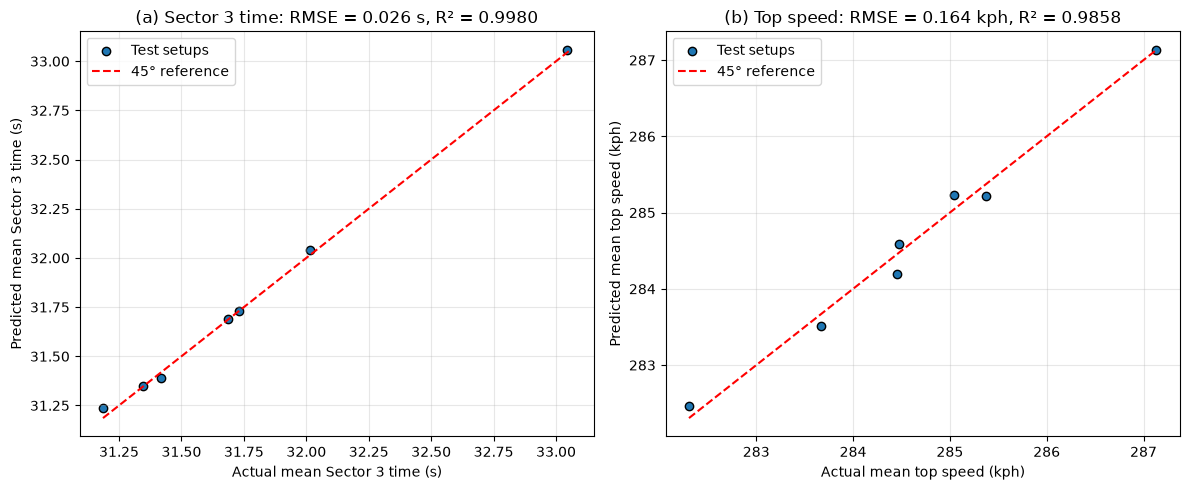

In [10]:
#15
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# (a) Sector 3 time
ax[0].scatter(y_time_test, yhat_time_test, edgecolor="k", label="Test setups")
lims = [min(y_time_test.min(), yhat_time_test.min()), max(y_time_test.max(), yhat_time_test.max())]
ax[0].plot(lims, lims, "r--", label="45° reference")
ax[0].set_xlabel("Actual mean Sector 3 time (s)")
ax[0].set_ylabel("Predicted mean Sector 3 time (s)")
ax[0].set_title(f"(a) Sector 3 time: RMSE = {rmse_time:.3f} s, R² = {r2_time:.4f}")
ax[0].legend()
ax[0].grid(alpha=0.3)

# (b) Top speed
ax[1].scatter(y_speed_test, yhat_speed_test, edgecolor="k", label="Test setups")
lims = [min(y_speed_test.min(), yhat_speed_test.min()), max(y_speed_test.max(), yhat_speed_test.max())]
ax[1].plot(lims, lims, "r--", label="45° reference")
ax[1].set_xlabel("Actual mean top speed (kph)")
ax[1].set_ylabel("Predicted mean top speed (kph)")
ax[1].set_title(f"(b) Top speed: RMSE = {rmse_speed:.3f} kph, R² = {r2_speed:.4f}")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"Wfrazer_pr02_validation.png", dpi=200)
plt.show()

Both surfaces predict the seven unseen setups well. The Sector 3 model has a test R² ≈ 0.998 and RMSE ≈ 0.026 s. That error is smaller than the typical lap-to-lap scatter within a setup (≈ 0.056 s), so the model error is below the measurement noise. The top-speed model has R² ≈ 0.986 and RMSE ≈ 0.16 kph, which is comparable to the within-setup scatter (≈ 0.21 kph). Both surfaces are credible enough to use as surrogates.

Limitations-

Only seven test setups were used.
A top-speed error of about 0.16 kph matters for the 284.0 kph constraint. A design predicted to sit exactly on the boundary could be slightly below it on track.
The data cover only 5–13° and 35–45 mm, with just three ride-height levels. Curvature in ride height is estimated from very little information, and nothing outside this region should be trusted.

In [11]:
#17
# Final models: refit using all 27 setups
x1_all = df_grouped["rear_wing_angle_deg"].values
x2_all = df_grouped["rear_ride_height_mm"].values
Xdm_all = create_design_matrix(x1_all, x2_all)

b_time = np.linalg.pinv(Xdm_all) @ df_grouped["mean_sector_3_time_s"].values
b_speed = np.linalg.pinv(Xdm_all) @ df_grouped["mean_top_speed_kph"].values

print("b_time: ", b_time)
print("b_speed:", b_speed)

b_time:  [47.689878 -1.296769 -0.496329  0.054714  0.005883  0.003697]
b_speed: [291.606388  -0.575057  -0.020175  -0.010205  -0.000822   0.002163]


In [12]:
#18
def predict_sector_time(x):
    x1, x2 = x
    return (b_time[0] + b_time[1]*x1 + b_time[2]*x2
            + b_time[3]*x1**2 + b_time[4]*x2**2 + b_time[5]*x1*x2)

def predict_top_speed(x):
    x1, x2 = x
    return (b_speed[0] + b_speed[1]*x1 + b_speed[2]*x2
            + b_speed[3]*x1**2 + b_speed[4]*x2**2 + b_speed[5]*x1*x2)

# Test at one tested setup: 9 deg, 40 mm
x_check = np.array([9, 40])
row = df_grouped[(df_grouped["rear_wing_angle_deg"] == 9) & (df_grouped["rear_ride_height_mm"] == 40)]

print("Predicted Sector 3 time (s):", predict_sector_time(x_check))
print("Measured mean Sector 3 time (s):", row["mean_sector_3_time_s"].values[0])
print("Predicted top speed (kph):", predict_top_speed(x_check))
print("Measured mean top speed (kph):", row["mean_top_speed_kph"].values[0])

Predicted Sector 3 time (s): 31.340928032708295
Measured mean Sector 3 time (s): 31.347379999999998
Predicted top speed (kph): 284.2602979316968
Measured mean top speed (kph): 284.452


In [13]:
#Task 3

In [14]:
#19
# Design bounds from the tested setups
wing_bounds = (df_grouped["rear_wing_angle_deg"].min(), df_grouped["rear_wing_angle_deg"].max())
ride_height_bounds = (df_grouped["rear_ride_height_mm"].min(), df_grouped["rear_ride_height_mm"].max())

print("Wing bounds (deg):", wing_bounds)
print("Ride height bounds (mm):", ride_height_bounds)

# Combined bounds in the format scipy.optimize expects: [(x1_min, x1_max), (x2_min, x2_max)]
bounds = [wing_bounds, ride_height_bounds]

Wing bounds (deg): (np.int64(5), np.int64(13))
Ride height bounds (mm): (np.int64(35), np.int64(45))


In [15]:
#20
# 101 evenly spaced values across each bound
x1_grid = np.linspace(wing_bounds[0], wing_bounds[1], 101)
x2_grid = np.linspace(ride_height_bounds[0], ride_height_bounds[1], 101)

# 2D grid of every wing / ride height combination
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Predicted Sector 3 time at every grid point
T_grid = predict_sector_time([X1, X2])

print("Grid shape:", T_grid.shape)
print("Wing spacing (deg):", x1_grid[1] - x1_grid[0])
print("Ride height spacing (mm):", x2_grid[1] - x2_grid[0])

Grid shape: (101, 101)
Wing spacing (deg): 0.08000000000000007
Ride height spacing (mm): 0.10000000000000142


In [16]:
#21
# Lowest predicted Sector 3 time on the grid
T_min_grid = np.min(T_grid)

# Position of that minimum (in the flattened grid)
idx = np.argmin(T_grid)

# Design variables at that position
x_grid_best = np.array([X1.flatten()[idx], X2.flatten()[idx]])

print("Best unconstrained grid point:")
print("  Rear-wing angle (deg):", x_grid_best[0])
print("  Rear ride height (mm):", x_grid_best[1])
print("  Predicted Sector 3 time (s):", T_min_grid)
print("  Predicted top speed (kph):", predict_top_speed(x_grid_best))

Best unconstrained grid point:
  Rear-wing angle (deg): 10.52
  Rear ride height (mm): 38.9
  Predicted Sector 3 time (s): 31.210586204804127
  Predicted top speed (kph): 283.2834515711543


In [17]:
#22

# Objective: predicted Sector 3 time for a design x = [wing, ride height]
def objective(x):
    return predict_sector_time(x)

In [18]:
#23
# Initial guess near the center of the tested region
x0 = np.array([np.mean(wing_bounds), np.mean(ride_height_bounds)])   # [9, 40]

# Bounds-only optimization
result_unconstrained = opt.minimize(objective, x0, method="L-BFGS-B", bounds=bounds)

#24
x_unc = result_unconstrained.x

print("Initial guess:", x0)
print("Success:", result_unconstrained.success)
print("Message:", result_unconstrained.message)
print("  Rear-wing angle (deg):", x_unc[0])
print("  Rear ride height (mm):", x_unc[1])
print("  Predicted Sector 3 time (s):", predict_sector_time(x_unc))
print("  Predicted top speed (kph):", predict_top_speed(x_unc))

Initial guess: [ 9. 40.]
Success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Rear-wing angle (deg): 10.537269348916107
  Rear ride height (mm): 38.873798776448176
  Predicted Sector 3 time (s): 31.21056753166433
  Predicted top speed (kph): 283.2728696818851


In [19]:
#25
# Grid spacing
dx1 = x1_grid[1] - x1_grid[0]
dx2 = x2_grid[1] - x2_grid[0]

# Difference between optimizer and best grid point
diff_x1 = abs(x_unc[0] - x_grid_best[0])
diff_x2 = abs(x_unc[1] - x_grid_best[1])
diff_T = abs(predict_sector_time(x_unc) - T_min_grid)

print("Wing difference (deg):", diff_x1, " | grid spacing:", dx1)
print("Ride height difference (mm):", diff_x2, " | grid spacing:", dx2)
print("Sector 3 time difference (s):", diff_T)
print("Within half a grid step:", diff_x1 <= dx1/2 and diff_x2 <= dx2/2)

Wing difference (deg): 0.01726934891610732  | grid spacing: 0.08000000000000007
Ride height difference (mm): 0.02620122355182275  | grid spacing: 0.10000000000000142
Sector 3 time difference (s): 1.8673139795311045e-05
Within half a grid step: True


The L-BFGS-B solution (10.54°, 38.87 mm) and the best grid point (10.52°, 38.90 mm) differ by about 0.02° and 0.03 mm. Both differences are less than half a grid step (0.04° and 0.05 mm), which is the closest the grid can possibly get to a point between its nodes. 
The predicted Sector 3 times agree to about 0.000025 s. So the two methods agree within the grid resolution, and the optimizer has found the true minimum of the surface. The minimum sits inside the tested region rather than on a bound, which fits the bowl shape of the quadratic. However, its predicted top speed (approximately 283.3 kph) is below the 284.0 kph requirement.

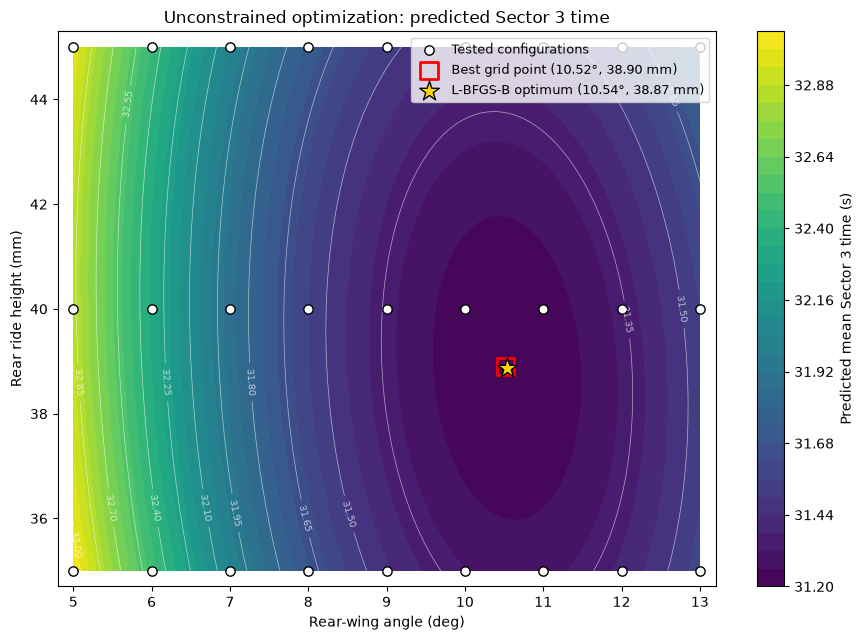

In [20]:
fig, ax = plt.subplots(figsize=(9, 6.5))
cf = ax.contourf(X1, X2, T_grid, levels=30, cmap="viridis")
cs = ax.contour(X1, X2, T_grid, levels=15, colors="white", linewidths=0.5, alpha=0.6)
ax.clabel(cs, fmt="%.2f", fontsize=7)
fig.colorbar(cf, ax=ax, label="Predicted mean Sector 3 time (s)")

ax.scatter(df_grouped["rear_wing_angle_deg"], df_grouped["rear_ride_height_mm"],
           c="white", edgecolor="k", s=45, label="Tested configurations", zorder=3)
ax.scatter(*x_grid_best, marker="s", s=160, facecolor="none", edgecolor="red", linewidth=2,
           label=f"Best grid point ({x_grid_best[0]:.2f}°, {x_grid_best[1]:.2f} mm)", zorder=4)
ax.scatter(*x_unc, marker="*", s=220, c="gold", edgecolor="k",
           label=f"L-BFGS-B optimum ({x_unc[0]:.2f}°, {x_unc[1]:.2f} mm)", zorder=5)

ax.set_xlim(wing_bounds[0]-0.2, wing_bounds[1]+0.2)
ax.set_ylim(ride_height_bounds[0]-0.3, ride_height_bounds[1]+0.3)
ax.set_xlabel("Rear-wing angle (deg)")
ax.set_ylabel("Rear ride height (mm)")
ax.set_title("Unconstrained optimization: predicted Sector 3 time")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(f"Wfrazer_pr02_unconstrained.png", dpi=200, bbox_inches="tight")
plt.show()

**Task 4**

In [21]:
#27
# Minimum required predicted top speed
V_min = 284.0

# Constraint function
def top_speed_constraint(x):
    return predict_top_speed(x) - V_min

In [22]:
#28
# Constraint in the format scipy expects
constraints = {"type": "ineq", "fun": top_speed_constraint}

# Constrained optimization: same objective, bounds, and starting point
result_constrained = opt.minimize(objective, x0, method="SLSQP",
                                  bounds=bounds, constraints=constraints)

In [23]:
#29
x_con = result_constrained.x
margin_con = top_speed_constraint(x_con)

print("Success:", result_constrained.success)
print("Message:", result_constrained.message)
print("  Rear-wing angle (deg):", x_con[0])
print("  Rear ride height (mm):", x_con[1])
print("  Predicted Sector 3 time (s):", predict_sector_time(x_con))
print("  Predicted top speed (kph):", predict_top_speed(x_con))
print("  Constraint margin (kph):", margin_con)

#30
is_active = abs(margin_con) < 0.05
print("Constraint active:", is_active)

Success: True
Message: Optimization terminated successfully
  Rear-wing angle (deg): 9.54182428483874
  Rear ride height (mm): 38.32769282380965
  Predicted Sector 3 time (s): 31.268548065291675
  Predicted top speed (kph): 283.99999998261177
  Constraint margin (kph): -1.738823129926459e-08
Constraint active: True


In [24]:
#31
# Substantially different starting points within the tested region
starts = [
    [9, 40],    # center
    [5, 35],    # low wing, low ride height (feasible corner)
    [13, 45],   # high wing, high ride height (infeasible corner)
    [6, 44],    # low wing, high ride height
    [12, 36]    # high wing, low ride height
]

rows = []
for s in starts:
    r = opt.minimize(objective, s, method="SLSQP", bounds=bounds, constraints=constraints)
    rows.append([
        s[0], s[1],
        r.x[0], r.x[1],
        predict_sector_time(r.x),
        predict_top_speed(r.x),
        top_speed_constraint(r.x),
        r.success
    ])

df_optimization_runs = pd.DataFrame(rows, columns=[
    "initial_x1", "initial_x2", "optimal_x1", "optimal_x2",
    "sector_time_s", "top_speed_kph", "constraint_margin_kph", "success"
])

In [25]:
#32
display(df_optimization_runs)
df_optimization_runs.to_csv(f"Wfrazer_pr02_optimization_runs.csv", index=False)

# How much do the answers differ?
print("Spread in optimal wing (deg):", df_optimization_runs["optimal_x1"].max() - df_optimization_runs["optimal_x1"].min())
print("Spread in optimal ride height (mm):", df_optimization_runs["optimal_x2"].max() - df_optimization_runs["optimal_x2"].min())
print("Spread in Sector 3 time (s):", df_optimization_runs["sector_time_s"].max() - df_optimization_runs["sector_time_s"].min())

,initial_x1,initial_x2,optimal_x1,optimal_x2,sector_time_s,top_speed_kph,constraint_margin_kph,success
0,9,40,9.541824,38.327693,31.268548,284.000000,-1.738823e-08,True
1,5,35,9.541827,38.327659,31.268548,284.000000,-7.230352e-08,True
2,13,45,9.541833,38.327595,31.268548,284.000000,-8.137135e-10,True
3,6,44,9.541816,38.327797,31.268548,283.999999,-9.512660e-07,True
4,12,36,9.541826,38.327676,31.268548,284.000000,-5.046957e-09,True


Spread in optimal wing (deg): 1.6955029726872795e-05
Spread in optimal ride height (mm): 0.00020133621243445532
Spread in Sector 3 time (s): 1.5345001358468835e-07


**Sensitivity to the initial guess.** I ran SLSQP from five starting points: the center of the tested region and all four corners. Two of those starts were feasible and two were infeasible. All five converged successfully to the same design, about 9.54° wing and 38.33 mm ride height. The optimal wing angles agree to about $10^{-6}$ deg, the ride heights to about $10^{-4}$ mm, and the predicted times to about $10^{-8}$ s, all far smaller than anything that could be set or measured on the car. So the result doesn't depend on where the optimizer starts. This is expected because the Sector 3 surface is a single smooth bowl and the top-speed boundary is a smooth curve, so there is only one constrained optimum inside the tested region.

In [26]:
#33
# Predicted top speed at every grid point (same grid as Task III)
V_grid = predict_top_speed([X1, X2])

# Boolean mask: True where the design meets the top-speed requirement
feasible = V_grid >= V_min

print("Feasible grid points:", feasible.sum(), "of", feasible.size)

Feasible grid points: 5569 of 10201


In [27]:
#34
# Replace infeasible times with infinity so they can never be picked
T_feasible = np.where(feasible, T_grid, np.inf)

idx_f = np.argmin(T_feasible)
x_grid_feas = np.array([X1.flatten()[idx_f], X2.flatten()[idx_f]])

print("Best feasible grid point:")
print("  Rear-wing angle (deg):", x_grid_feas[0])
print("  Rear ride height (mm):", x_grid_feas[1])
print("  Predicted Sector 3 time (s):", predict_sector_time(x_grid_feas))
print("  Predicted top speed (kph):", predict_top_speed(x_grid_feas))

print("Difference from SLSQP:")
print("  Wing (deg):", x_grid_feas[0] - x_con[0])
print("  Ride height (mm):", x_grid_feas[1] - x_con[1])
print("  Sector 3 time (s):", predict_sector_time(x_grid_feas) - predict_sector_time(x_con))

Best feasible grid point:
  Rear-wing angle (deg): 9.56
  Rear ride height (mm): 38.1
  Predicted Sector 3 time (s): 31.269140200449748
  Predicted top speed (kph): 284.0017060414344
Difference from SLSQP:
  Wing (deg): 0.018175715161261152
  Ride height (mm): -0.2276928238096474
  Sector 3 time (s): 0.0005921351580724377


**Grid verification.** The best feasible grid point (9.56°, 38.10 mm) is within one grid step of the SLSQP solution in wing angle and about two grid steps in ride height, and its predicted Sector 3 time is only about 0.0006 s slower. It sits just inside the feasible region (284.002 kph) because it has to land on a grid node, while SLSQP can sit exactly on the 284.0 kph boundary. The slightly larger ride-height difference reflects how flat the time surface is along the constraint in that direction. The brute-force grid search therefore confirms the SLSQP result.

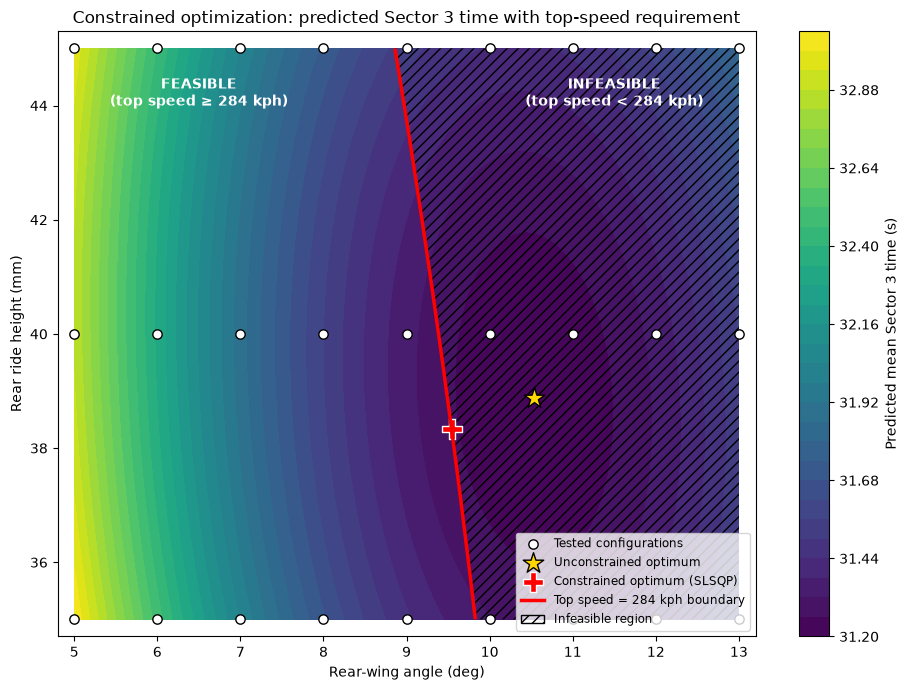

In [28]:
#35 36 37
plt.figure(figsize=(9.5, 7))

# 35. Contours of predicted Sector 3 time
plt.contourf(X1, X2, T_grid, levels=30, cmap="viridis")
plt.colorbar(label="Predicted mean Sector 3 time (s)")

# 36. Hatch the infeasible region and draw the 284 kph boundary
plt.contourf(X1, X2, V_grid, levels=[V_grid.min(), V_min], colors="none", hatches=["///"])
plt.contour(X1, X2, V_grid, levels=[V_min], colors="red", linewidths=2.5)

# Label each side of the boundary
plt.text(6.5, 44, "FEASIBLE\n(top speed ≥ 284 kph)", color="white", fontweight="bold", ha="center")
plt.text(11.5, 44, "INFEASIBLE\n(top speed < 284 kph)", color="white", fontweight="bold", ha="center")

# Tested setups and solutions
plt.scatter(df_grouped["rear_wing_angle_deg"], df_grouped["rear_ride_height_mm"],
            c="white", edgecolor="k", s=45, label="Tested configurations")
plt.scatter(x_unc[0], x_unc[1], marker="*", s=240, c="gold", edgecolor="k",
            label="Unconstrained optimum")
plt.scatter(x_con[0], x_con[1], marker="P", s=200, c="red", edgecolor="white",
            label="Constrained optimum (SLSQP)")

# Legend entries for the boundary and hatching (contours don't add these automatically)
plt.plot([], [], "r-", linewidth=2.5, label="Top speed = 284 kph boundary")
plt.fill([], [], facecolor="none", edgecolor="k", hatch="///", label="Infeasible region")

plt.xlim(wing_bounds[0] - 0.2, wing_bounds[1] + 0.2)
plt.ylim(ride_height_bounds[0] - 0.3, ride_height_bounds[1] + 0.3)
plt.xlabel("Rear-wing angle (deg)")
plt.ylabel("Rear ride height (mm)")
plt.title("Constrained optimization: predicted Sector 3 time with top-speed requirement")
plt.legend(loc="lower right", fontsize=8.5)
plt.tight_layout()

# 37. Save
plt.savefig(f"Wfrazer_pr02_constrained.png", dpi=200)
plt.show()

In [29]:
#38
T_unc = predict_sector_time(x_unc)
V_unc = predict_top_speed(x_unc)
T_con = predict_sector_time(x_con)
V_con = predict_top_speed(x_con)

print("Unconstrained:", x_unc, " T =", T_unc, " V =", V_unc)
print("Constrained:  ", x_con, " T =", T_con, " V =", V_con)
print("Change in Sector 3 time (s):", T_con - T_unc)
print("Change in top speed (kph):", V_con - V_unc)
print("Change in wing (deg):", x_con[0] - x_unc[0])
print("Change in ride height (mm):", x_con[1] - x_unc[1])

Unconstrained: [10.537269 38.873799]  T = 31.21056753166433  V = 283.2728696818851
Constrained:   [ 9.541824 38.327693]  T = 31.268548065291675  V = 283.99999998261177
Change in Sector 3 time (s): 0.05798053362734379
Change in top speed (kph): 0.7271303007266852
Change in wing (deg): -0.9954450640773675
Change in ride height (mm): -0.546105952638527


**Unconstrained vs. constrained results** The unconstrained optimum (approx 10.54°, 38.87 mm) gives the fastest predicted Sector 3 time, 31.211 s, but only 283.27 kph top speed, about 0.73 kph short of the requirement. 

Adding the 284.0 kph constraint moves the design to approx 9.54°, 38.33 mm: about 1° less rear wing and 0.5 mm lower rear ride height. This costs about +0.058 s in predicted Sector 3 time and gains about +0.73 kph of predicted top speed.

The constrained solution is the more defensible recommendation for three reasons:
1. The extra wing only helps through Sector 3, while the lost straight-line speed hurts on the front straight, in overtaking and defending, and in the following sector.
2. The time cost is small because the surface is flat near its minimum, while the speed gain is what is required.
3. Taking wing angle out, you would expect the recovery of top speed, so the result makes engineering sense.

In [30]:
#39
def penalized_objective(x, rho):
    violation = max(0, V_min - predict_top_speed(x))
    return predict_sector_time(x) + rho * violation**2

In [31]:
#40
rows = []
for rho in [0.1, 1, 10, 100]:
    # Same starting point and bounds every time, no explicit constraint
    r = opt.minimize(penalized_objective, x0, args=(rho,), method="L-BFGS-B", bounds=bounds)
    rows.append([
        rho,
        r.x[0], r.x[1],
        predict_sector_time(r.x),
        predict_top_speed(r.x),
        max(0, V_min - predict_top_speed(r.x)),
        penalized_objective(r.x, rho)
    ])
    if rho == 100:
        x_pen100 = r.x     # keep for the recommendation table

#41
df_penalty = pd.DataFrame(rows, columns=[
    "rho", "rear_wing_angle_deg", "rear_ride_height_mm",
    "sector_time_s", "top_speed_kph", "violation_kph", "penalized_objective"
])

#42
display(df_penalty)
df_penalty.to_csv(f"Wfrazer_pr02_penalty.csv", index=False)

print("rho = 100 vs SLSQP:")
print("  Wing difference (deg):", x_pen100[0] - x_con[0])
print("  Ride height difference (mm):", x_pen100[1] - x_con[1])

,rho,rear_wing_angle_deg,rear_ride_height_mm,sector_time_s,top_speed_kph,violation_kph,penalized_objective
0,0.1,10.062882,38.624205,31.223685,283.621020,0.378980,31.238047
1,1.0,9.641819,38.386173,31.257452,283.927561,0.072439,31.262699
2,10.0,9.552861,38.334107,31.267266,283.992016,0.007984,31.267903
3,100.0,9.542940,38.328335,31.268418,283.999193,0.000807,31.268483


rho = 100 vs SLSQP:
  Wing difference (deg): 0.0011157894736228968
  Ride height difference (mm): 0.000642140687048709


**Effect of the penalty parameter.** With a small penalty $\rho = 0.1$, breaking the top-speed rule costs very little, so the optimizer keeps about 10.06° of wing and misses the requirement by 0.38 kph. As $\rho$ increases, the design moves toward less wing and slightly lower ride height, and the violation shrinks by roughly 10x each time $\rho$ increases by 10 (0.38, 0.072, 0.008, 0.0008 kph). This is about $1/\rho$ behavior. The Sector 3 time rises toward the SLSQP value as this happens.

At $\rho = 100$ the design (9.543°, 38.328 mm) is within about 0.001° and 0.001 mm of the SLSQP solution, but it is still **slightly infeasible** (0.0008 kph below 284.0). 

This is built into the quadratic penalty: it only acts once the constraint is broken, so for any finite $\rho$ the minimum sits just outside the boundary. It only reaches the exact constrained optimum as $\rho \to \infty$, and very large $\rho$ makes the problem numerically harder to solve. The explicit SLSQP constraint handles the requirement exactly, so it is the better method in this case.

In [32]:
#44
designs = {
    "Unconstrained (L-BFGS-B)": x_unc,
    "Constrained (SLSQP)": x_con,
    "Best feasible grid point": x_grid_feas,
    "Penalty rho = 100": x_pen100
}

rows = []
for name, x in designs.items():
    margin = predict_top_speed(x) - V_min
    rows.append([
        name, x[0], x[1],
        predict_sector_time(x),
        predict_top_speed(x),
        margin,
        margin >= -1e-6    # small tolerance for solver round-off
    ])

df_recommendation = pd.DataFrame(rows, columns=[
    "solution", "rear_wing_angle_deg", "rear_ride_height_mm",
    "sector_time_s", "top_speed_kph", "constraint_margin_kph", "feasible"
])
display(df_recommendation)
df_recommendation.to_csv(f"Wfrazer_pr02_recommendation.csv", index=False)

,solution,rear_wing_angle_deg,rear_ride_height_mm,sector_time_s,top_speed_kph,constraint_margin_kph,feasible
0,Unconstrained (L-BFGS-B),10.537269,38.873799,31.210568,283.272870,-7.271303e-01,False
1,Constrained (SLSQP),9.541824,38.327693,31.268548,284.000000,-1.738823e-08,True
2,Best feasible grid point,9.560000,38.100000,31.269140,284.001706,1.706041e-03,True
3,Penalty rho = 100,9.542940,38.328335,31.268418,283.999193,-8.066520e-04,False


In [33]:
#45
x_rec = x_con
print("FINAL MODEL-BASED RECOMMENDED CANDIDATE (requires verification):")
print("  Rear-wing angle (deg):", round(x_rec[0], 2))
print("  Rear ride height (mm):", round(x_rec[1], 2))
print("  Predicted Sector 3 time (s):", round(predict_sector_time(x_rec), 3))
print("  Predicted top speed (kph):", round(predict_top_speed(x_rec), 2))

FINAL MODEL-BASED RECOMMENDED CANDIDATE (requires verification):
  Rear-wing angle (deg): 9.54
  Rear ride height (mm): 38.33
  Predicted Sector 3 time (s): 31.269
  Predicted top speed (kph): 284.0


## Final Recommendation

**Recommended candidate:** rear-wing angle approx 9.54°** and rear ride height approx **38.3 mm** (the SLSQP solution), with predicted Sector 3 time approx 31.269 s and predicted top speed 284.0 kph. 

I chose this as this conbfiguration is feasible, it was reached from five very different starting points, it agrees with the best feasible grid point, and it lies inside the tested region where both models are validated well. 

If the wing can only be set in 0.5 degree steps, I would go to 9.5 degrees, to also stay feasible.

**Why it is preferable to the unconstrained minimum.** The unconstrained setup is only about 0.058 s faster through Sector 3, but it gives up about 0.73 kph of top speed and fails the project requirement. The recommended setup gives up a small amount of Sector 3 time to keep the straight-line speed the team needs for the front straight and for racing.

**Is the constraint active, and what does it mean physically?** Yes. The margin is essentially zero, so the design sits on the 284.0 kph boundary. Physically, the car is drag-limited: more wing would still help Sector 3, but the top-speed requirement caps it, so the best legal setup runs as much rear wing as the requirement allows.

**Do the optimizer and grid verification agree?** Yes. For the unconstrained problem, L-BFGS-B and the grid agree within half a grid step. For the constrained problem, the best feasible grid point is within about 0.02° and 0.23 mm of SLSQP and only about 0.0006 s slower, because the grid has to land on a node just inside the feasible region.

**How does the penalty parameter affect feasibility?** Small $\rho$ allows a clear violation (0.38 kph at $\rho = 0.1$). Increasing $\rho$ pushes the design toward the boundary, and the violation falls roughly as $1/\rho$. Even at $\rho = 100$ the design is still slightly infeasible, which is typical of an exterior quadratic penalty, so the explicit SLSQP constraint is more reliable.

**Why this is not a confirmed physical optimum.** This is the optimum of a fitted quadratic, not of the car:
1. The models are based on 27 setup averages on a coarse grid, with only three ride-height levels.
2. The recommended setup (9.54°, 38.3 mm) was never actually run.
3. The top-speed model's test RMSE (about 0.16 kph) is about the same size as the distance to the constraint, so the real top speed could be slightly below 284 kph.
4. The models ignore outside factors such as fuel load, tyre condition, wind, track temperature, traffic.

**Recommended verification:**
1. Run the candidate for at least five laps, back to back with a baseline setup in the same session, to compare mean Sector 3 time and top speed under the same track conditions.
2. Run bracketing setups around the candidate (about ±0.5° wing and ±2.5 mm ride height) to confirm the local trend, then refit the surfaces with the new data.
3. Before real track time, check the drag and downforce change with CFD, a lap-time simulation or through discussion, and ensure that the rake change from the lower rear ride height doesn't upset the car's balance or platform.